### 2-6-6. 의사결정 나무

Accuracy: 0.8524590163934426
Confusion Matrix:
 [[26  3]
 [ 6 26]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.90      0.85        29
           1       0.90      0.81      0.85        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.86      0.85      0.85        61



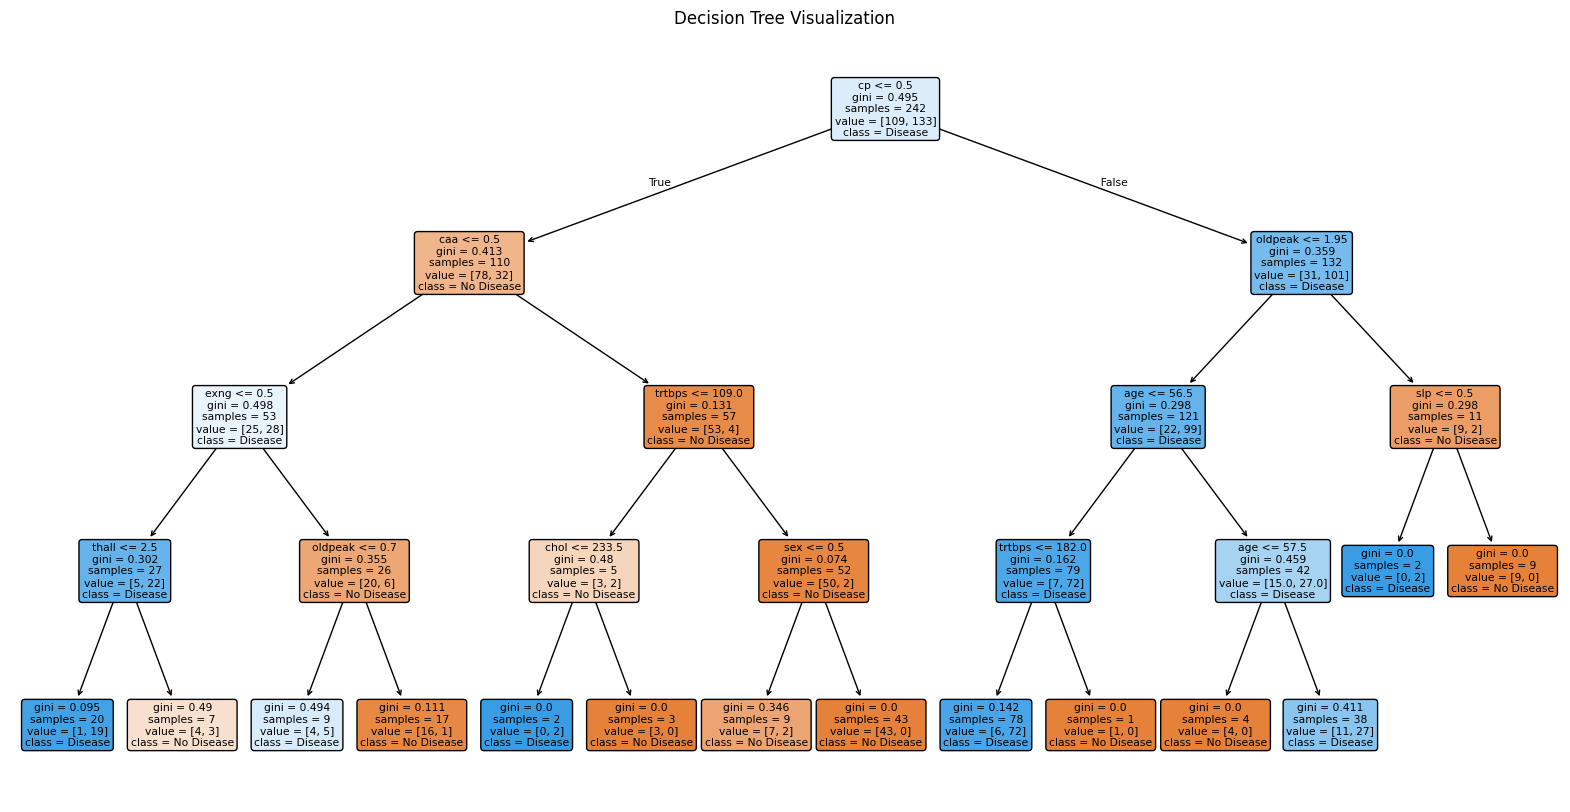

In [1]:
# 필요한 라이브러리 불러오기 
import pandas as pd # 데이터 처리 
from sklearn.model_selection import train_test_split # 데이터 분리 
from sklearn.tree import DecisionTreeClassifier # 의사결정 나무 모델 
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 평가 지표 
import matplotlib.pyplot as plt # 시각화 
from sklearn.tree import plot_tree # 의사결정 나무 시각화

# 1. 데이터 로드 
data = pd.read_csv('../datasets/heart.csv')

# 2. 입력(X)과 출력(y) 분리 
X = data.drop('output', axis=1) # 'output'을 제외한 모든 열 
y = data['output'] # 심장병 여부 (1: 있음, 0: 없음)

# 3. 데이터를 학습용과 테스트용으로 나누기 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. 모델 생성 및 학습 
model = DecisionTreeClassifier(max_depth=4, random_state=42) # 트리 깊이 제한 
model.fit(X_train, y_train)

# 5. 테스트 데이터로 예측 
y_pred = model.predict(X_test)

# 6. 모델 평가 
accuracy = accuracy_score(y_test, y_pred) # 정확도 계산 
conf_matrix = confusion_matrix(y_test, y_pred) # 혼동 행렬 계산 
report = classification_report(y_test, y_pred) # 정밀도, 재현율, F1 스코어 계산

# 평가 결과 출력 
print("Accuracy:", accuracy) 
print("Confusion Matrix:\n", conf_matrix) 
print("Classification Report:\n", report)

# 7. 의사결정 나무 시각화 
plt.figure(figsize=(20, 10)) 
plot_tree(model, feature_names=X.columns, class_names=["No Disease", "Disease"], filled=True, rounded=True) 
plt.title("Decision Tree Visualization") 
plt.show()